In [9]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import torch

/Users/laurenpearson/Desktop/Transcriptformer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
adata = sc.read_h5ad("s_fca_biohub_all_wo_blood_10x.h5ad")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 's_fca_biohub_all_wo_blood_10x.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
adata.obs.columns

NameError: name 'adata' is not defined

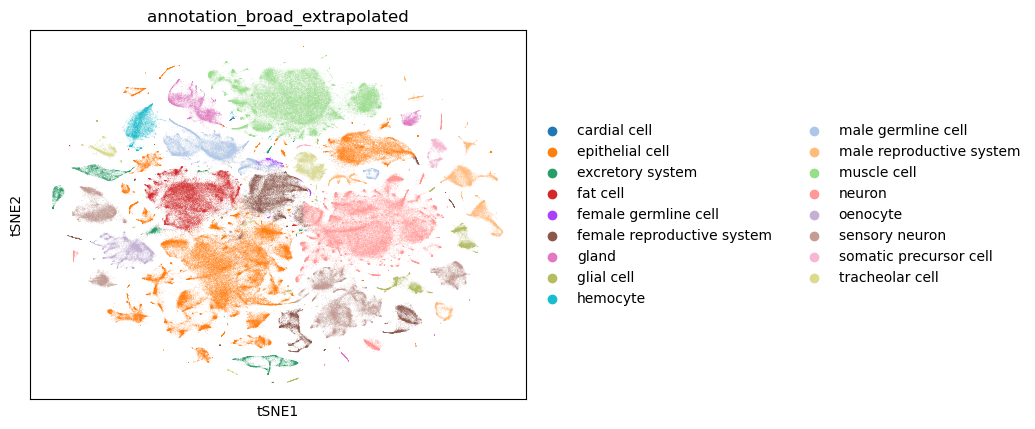

In [ ]:
sc.pl.tsne(adata, color='annotation_broad_extrapolated')

In [ ]:
print(f"Sex table:\n{adata.obs['sex'].value_counts()}")
print(f"Age table:\n{adata.obs['age'].value_counts()}")
print(f"Cell type table:\n{adata.obs['annotation_broad_extrapolated'].value_counts()}")
print(f"Annotation table:\n{adata.obs['annotation'].value_counts()}")

Sex table:
sex
female    254580
male      236486
mix        15594
Name: count, dtype: int64
Age table:
age
5    416017
1     43454
3     26926
2     20263
Name: count, dtype: int64
Cell type table:
annotation_broad_extrapolated
epithelial cell               129730
neuron                         84711
muscle cell                    63421
sensory neuron                 44397
female reproductive system     34933
fat cell                       32766
male reproductive system       21287
male germline cell             20806
gland                          12635
tracheolar cell                12618
glial cell                     12204
excretory system               11702
oenocyte                       10908
hemocyte                        8394
somatic precursor cell          4371
female germline cell            1504
cardial cell                     273
Name: count, dtype: int64
Annotation table:
annotation
unannotated                                                                      109988


In [ ]:
len(adata)

506660

In [ ]:
adata_filtered = adata[
    (adata.obs['sex'].isin(['male', 'female'])) &
    (adata.obs['annotation'] != 'unannotated')
].copy()


In [ ]:
def generate_fca_captions(adata):
    """
    Generate deterministic captions for Fly Cell Atlas cells.
    
    Template:
    "A <broad cell type> from Drosophila melanogaster, derived from a <sex> adult fly at <age> days post eclosion."
    
    Parameters
    ----------
    adata : AnnData
        Should have the following columns in adata.obs:
        - 'annotation_broad_extrapolated' (broad cell type)
        - 'sex' ('male', 'female', 'mixed')
        - 'age' (int)
        
    Returns
    -------
    captions : list of str
        One caption per cell in adata.obs
    """
    
    captions = []
    
    sex_map = {
        "male": "male",
        "female": "female",
        "mixed": "mixed"  # optionally discard these cells beforehand
    }
    
    for idx, row in adata.obs.iterrows():
        broad_type = row['annotation_broad_extrapolated']
        sex = sex_map.get(row['sex'].lower(), "unknown")
        age = row['age']
        annotation = row['annotation']
        
        caption = (f"A {broad_type} from Drosophila melanogaster, "
                   f"derived from a {sex} adult fly at {age} days post eclosion. Cell Type: {annotation}")
        captions.append(caption)
    
    return captions

In [ ]:
adata_filtered.obs['caption'] = generate_fca_captions(adata_filtered)

# Quick sanity check
adata_filtered.obs['caption'][1]

NameError: name 'generate_fca_captions' is not defined

In [ ]:
adata_filtered.obs['caption'][10000]

/var/folders/x9/q5003tld34s9w4y_0fsd7yb00000gn/T/ipykernel_87147/239381897.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata_filtered.obs['caption'][10000]


'A fat cell from Drosophila melanogaster, derived from a female adult fly at 3 days post eclosion. Cell Type: adult fat body'

In [ ]:
def get_expression_embedding(adata, method='pca', n_components=50):
    """
    Get expression embeddings for cells
    
    Parameters:
    -----------
    adata : AnnData
    method : str
        'pca' - Use existing or compute PCA
        'vae' - Use scVI or other VAE (future)
    n_components : int
        Dimension of embedding
        
    Returns:
    --------
    embeddings : np.ndarray, shape (n_cells, n_components)
    """
    
    if method == 'pca':
        # Check if PCA already exists (from Seurat)
        if 'X_pca' in adata.obsm:
            print(f"Using existing PCA embeddings")
            pca_full = adata.obsm['X_pca']
            # Take first n_components
            embeddings = pca_full[:, :n_components]
            print(f"  Shape: {embeddings.shape}")
            
        else:
            # Compute PCA in scanpy
            print(f"Computing PCA with {n_components} components...")
            sc.pp.pca(adata, n_comps=n_components)
            embeddings = adata.obsm['X_pca']
            print(f"  Shape: {embeddings.shape}")
        
        return embeddings

In [ ]:
expression_emb = get_expression_embedding(adata_filtered)

Using existing PCA embeddings
  Shape: (386000, 50)


In [ ]:
def encode_all_text(adata, model_name='dmis-lab/biobert-base-cased-v1.1', batch_size=32):
    """Encode all cell text descriptions with BioBERT"""
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    
    texts = adata.obs['caption'].tolist()
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding text"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                          return_tensors="pt", max_length=128)
        
        with torch.no_grad():
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state[:, 0, :].numpy()  # [CLS] token
        
        all_embeddings.append(embeddings)
    
    return np.vstack(all_embeddings)

# Encode all text
#let's try BERT instead
model_name = 'bert-base-uncased'
#or a sentence transformer
model_name = 'sentence-transformers/all-mpnet-base-v2'

text_emb = encode_all_text(adata_filtered, batch_size=32)

Encoding text: 100%|█████████████████| 12063/12063 [2:34:29<00:00,  1.30it/s]


In [ ]:
len(text_emb)

386000

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Set seed
np.random.seed(42)

# Stratified split by cell type (maintain proportions)
indices = np.arange(len(adata_filtered))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.05,  # 5% holdout
    stratify=adata_filtered.obs['annotation'],
    random_state=42
)

# Save splits
adata_filtered.obs['split'] = 'train'
adata_filtered.obs.loc[adata_filtered.obs.index[test_idx], 'split'] = 'test'

# Extract embeddings
train_cell_emb = expression_emb[train_idx]
train_text_emb = text_emb[train_idx]
test_cell_emb = expression_emb[test_idx]
test_text_emb = text_emb[test_idx]

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Adapter(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )

    def forward(self, x):
        return self.net(x)

class CellCLIP(nn.Module):
    def __init__(self, cell_dim, text_dim, projection_dim=2048):
        super().__init__()

        self.cell_adapter = Adapter(
            in_dim=cell_dim,
            hidden_dim=projection_dim,
            out_dim=projection_dim
        )

        self.text_adapter = Adapter(
            in_dim=text_dim,
            hidden_dim=projection_dim,
            out_dim=projection_dim
        )

        self.logit_scale = nn.Parameter(
            torch.ones([]) * torch.log(torch.tensor(1 / 0.07))
        )

    def forward(self, cell_emb, text_emb):
        cell_features = self.cell_adapter(cell_emb)
        text_features = self.text_adapter(text_emb)

        cell_features = F.normalize(cell_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        return cell_features, text_features

In [ ]:
## Initialize the model

cell_dim = expression_emb.shape[1]
text_dim = text_emb.shape[1]
print(cell_dim, text_dim)
model = CellCLIP(cell_dim, text_dim)

50 768


In [ ]:
from torch.utils.data import Dataset, DataLoader

class CellTextDataset(Dataset):
    def __init__(self, cell_emb, text_emb):
        self.cell_emb = torch.FloatTensor(cell_emb)
        self.text_emb = torch.FloatTensor(text_emb)
        
    def __len__(self):
        return len(self.cell_emb)
    
    def __getitem__(self, idx):
        return self.cell_emb[idx], self.text_emb[idx]

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

# Dataset class
class CellTextDataset(Dataset):
    def __init__(self, cell_emb, text_emb):
        self.cell_emb = torch.FloatTensor(cell_emb)
        self.text_emb = torch.FloatTensor(text_emb)
        
    def __len__(self):
        return len(self.cell_emb)
    
    def __getitem__(self, idx):
        return self.cell_emb[idx], self.text_emb[idx]

# Standardize PCA embeddings
scaler = StandardScaler()
expression_emb_scaled = scaler.fit_transform(expression_emb)
#print("Scaled PCA stats:")
for ct in adata_filtered.obs['annotation'].unique():
    mask = adata_filtered.obs['annotation'] == ct
    ct_pca = expression_emb_scaled[mask]
#    print(f"{ct:20s}: PC1 mean={ct_pca[:, 0].mean():.2f}, std={ct_pca[:, 0].std():.2f}")

# Re-split with scaled data
train_cell_emb_scaled = expression_emb_scaled[train_idx]
test_cell_emb_scaled = expression_emb_scaled[test_idx]

# Create dataloaders
train_dataset = CellTextDataset(train_cell_emb_scaled, train_text_emb)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)

test_dataset = CellTextDataset(test_cell_emb_scaled, test_text_emb)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
def clip_loss(similarity_matrix):
    """
    similarity_matrix: Tensor of shape (B, B)
    Entry (i, j) is similarity between cell i and text j
    """
    batch_size = similarity_matrix.size(0)
    device = similarity_matrix.device

    # Ground truth: diagonal alignment
    labels = torch.arange(batch_size, device=device)

    # Cell → text
    loss_c2t = F.cross_entropy(similarity_matrix, labels)

    # Text → cell
    loss_t2c = F.cross_entropy(similarity_matrix.T, labels)

    return (loss_c2t + loss_t2c) / 2

def train_epoch(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    
    for cell_emb, text_emb in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        
        # Forward pass
        cell_features, text_features = model(cell_emb, text_emb)
        
        # Compute similarity matrix
        logit_scale = model.logit_scale.exp()
        similarity_matrix = (cell_features @ text_features.T) * logit_scale
        
        # CLIP loss
        loss = clip_loss(similarity_matrix)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            model.logit_scale.clamp_(
                min=torch.log(torch.tensor(1/100, device=model.logit_scale.device)),
                max=torch.log(torch.tensor(100.0, device=model.logit_scale.device))
            )
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate(model, test_loader, recall_k=5):
    model.eval()

    total_loss = 0.0
    total_pos = 0.0
    total_neg = 0.0
    total_gap = 0.0
    cell_recall = 0
    total_samples = 0
    text_recall = 0

    with torch.no_grad():
        for cell_emb, text_emb in test_loader:
            cell_features, text_features = model(cell_emb, text_emb)

            logit_scale = model.logit_scale.exp()
            sim = (cell_features @ text_features.T) * logit_scale

            # InfoNCE loss
            loss = clip_loss(sim)
            total_loss += loss.item()

            batch_size = sim.size(0)
            total_samples += batch_size

            # Positive similarities (diagonal)
            pos = sim.diag()
            total_pos += pos.mean().item()

            # Negative similarities (row-wise mean excluding diagonal)
            neg = (sim.sum(dim=1) - pos) / (batch_size - 1)
            total_neg += neg.mean().item()

            # Gap diagnostic
            total_gap += (pos - neg).mean().item()

            # Recall@K cell
            topk = sim.topk(recall_k, dim=1).indices
            labels = torch.arange(batch_size, device=sim.device).unsqueeze(1)
            cell_recall += (topk == labels).any(dim=1).sum().item()

            # Recall@K text
            topk_text = sim.topk(recall_k, dim=0).indices
            labels = torch.arange(batch_size, device=sim.device).unsqueeze(0)
            text_recall = (topk_text == labels).any(dim=0).float().mean()
    
    avg_loss = total_loss / len(test_loader)
    avg_pos = total_pos / len(test_loader)
    avg_neg = total_neg / len(test_loader)
    avg_gap = total_gap / len(test_loader)
    cell_recall_at_k = cell_recall / total_samples
    text_recall_at_k = text_recall / total_samples
    
    return {
        "loss": avg_loss,
        "pos_sim": avg_pos,
        "neg_sim": avg_neg,
        "gap": avg_gap,
        f"cell_recall@{recall_k}": cell_recall_at_k,
        f"text_recall@{recall_k}": text_recall_at_k
    }

In [ ]:
num_epochs = 15
best_test_loss = float('inf')
history = {
    'train_loss': [],
    'test_loss': [],
    'pos_sim': [],
    'neg_sim': [],
    'gap': [],
    'cell_recall@5': [],
    'text_recall@5': []
}

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer)
    
    # Evaluate
    metrics = evaluate(model, test_loader, recall_k=5)
    
    # Update scheduler
    scheduler.step()
    
    # Track history
    history['train_loss'].append(train_loss)
    history['test_loss'].append(metrics['loss'])
    history['pos_sim'].append(metrics['pos_sim'])
    history['neg_sim'].append(metrics['neg_sim'])
    history['gap'].append(metrics['gap'])
    history['text_recall@5'].append(metrics['text_recall@5'])
    history['cell_recall@5'].append(metrics['cell_recall@5'])
    
    # Print progress
    print(
        f"Epoch {epoch+1:03d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {metrics['loss']:.4f} | "
        f"Gap: {metrics['gap']:.3f} | "
        f"R@5: {metrics['text_recall@5']:.3f} | "
        f"R@5: {metrics['cell_recall@5']:.3f} | "
        f"LR: {scheduler.get_last_lr()[0]:.2e}"
    )
    
    # Save best model
    if metrics['loss'] < best_test_loss:
        best_test_loss = metrics['loss']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics':metrics
        }, 'best_clip_model.pt')
        print(f"  ✓ Saved best model (test loss: {metrics['loss']:.4f})")

print("\n" + "="*60)
print("Training complete!")
print(f"Best test loss: {best_test_loss:.4f}")
print("="*60)

NameError: name 'train_epoch' is not defined

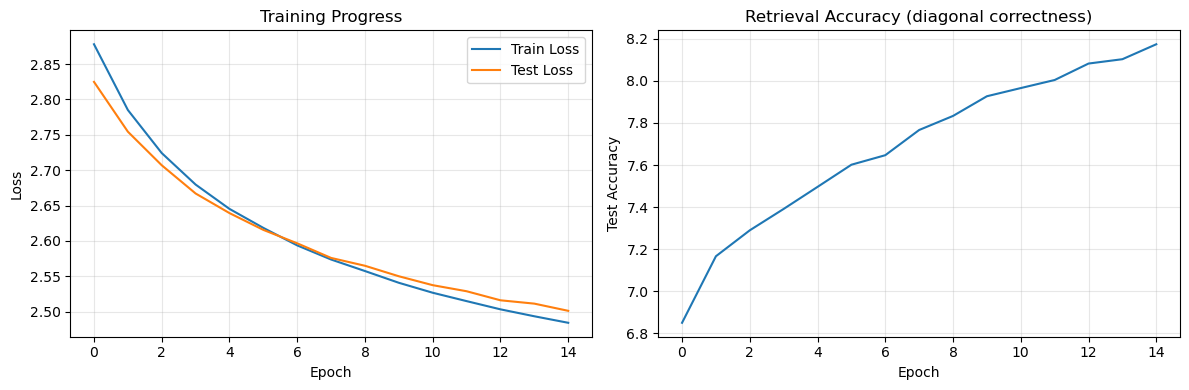

Final test accuracy: 8.174


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Progress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['gap'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Retrieval Accuracy (diagonal correctness)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Final test accuracy: {history['gap'][-1]:.3f}")

In [ ]:
# Load best model
checkpoint = torch.load('best_clip_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")

# Quick sanity checks
print("\n" + "="*60)
print("ZERO-SHOT QUERIES")
print("="*60)

# Simple cell type queries
queries = [
    "neuron",
    "muscle",
    "proboscis"
]

# For each query, see what cell types rank highest
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
biobert = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
biobert.eval()

for query_text in queries:
    # Encode query
    inputs = tokenizer(query_text, return_tensors="pt", max_length=128, truncation=True)
    with torch.no_grad():
        outputs = biobert(**inputs)
        query_emb = outputs.last_hidden_state[:, 0, :]
        query_features = model.text_adapter(query_emb)
        query_features = F.normalize(query_features, dim=-1)
    
    # Compare to test cells
    test_cell_torch = torch.FloatTensor(test_cell_emb)
    with torch.no_grad():
        cell_features = model.cell_adapter(test_cell_torch)
        cell_features = F.normalize(cell_features, dim=-1)
    
    # Compute similarities
    similarities = (cell_features @ query_features.T).squeeze().numpy()
    
    # Get top 100 cells
    top_100_idx = np.argsort(similarities)[-100:][::-1]
    top_cell_types = adata_filtered.obs.iloc[test_idx[top_100_idx]]['annotation'].value_counts()
    
    print(f"\nQuery: '{query_text}'")
    print(f"Top cell types in top-100:")
    print(top_cell_types.head())
    print(f"Similarity range: [{similarities.min():.3f}, {similarities.max():.3f}]")

✓ Loaded best model from epoch 15

ZERO-SHOT QUERIES


/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Query: 'neuron'
Top cell types in top-100:
annotation
adult reticular neuropil associated glial cell    15
ensheathing glial cell                            15
adult brain perineurial glial cell                 8
adult ventral nervous system                       6
dopaminergic PAM neuron                            5
Name: count, dtype: int64
Similarity range: [-0.277, 0.223]

Query: 'muscle'
Top cell types in top-100:
annotation
hemocyte                                                             55
adult antenna glial cell                                              5
adult abdominal pericardial cell                                      5
muscle cell                                                           4
btl-GAL4 positive female cell, cluster 2, likely to be ovary cell     3
Name: count, dtype: int64
Similarity range: [-0.223, 0.170]

Query: 'proboscis'
Top cell types in top-100:
annotation
muscle cell                                       23
adult lamina epithelial/marginal g

In [ ]:
def query_cells(model, query_text, adata, expression_emb, return_scores=True):
    """
    Query cells with natural language
    
    Parameters:
    -----------
    model : trained CellCLIP model
    query_text : str, e.g., "cells involved in inter-brain communication"
    adata : AnnData with cell metadata
    expression_emb : cell expression embeddings (PCA)
    
    Returns:
    --------
    similarities : array of similarity scores for each cell
    """
    model.eval()
    
    # Encode query text with BioBERT
    tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    biobert = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    biobert.eval()
    
    inputs = tokenizer(query_text, return_tensors="pt", max_length=128, truncation=True)
    with torch.no_grad():
        outputs = biobert(**inputs)
        query_emb = outputs.last_hidden_state[:, 0, :].numpy()  # [CLS] token
    
    # Project query to CLIP space
    query_emb_torch = torch.FloatTensor(query_emb)
    with torch.no_grad():
        query_features = model.text_adapter(query_emb_torch)
        query_features = F.normalize(query_features, dim=-1)
    
    # Project all cells to CLIP space
    cell_emb_torch = torch.FloatTensor(expression_emb)
    with torch.no_grad():
        cell_features = model.cell_adapter(cell_emb_torch)
        cell_features = F.normalize(cell_features, dim=-1)
    
    # Compute similarities (cosine similarity in CLIP space)
    similarities = (cell_features @ query_features.T).squeeze().numpy()
    
    return similarities


def visualize_query(model, query_text, adata, expression_emb, coords=None):
    """
    Visualize query results on tSNE
    """
    import matplotlib.pyplot as plt
    
    # Get similarities
    similarities = query_cells(model, query_text, adata, expression_emb)
    
    # Plot on tSNE
    if coords is None:
        # Use existing UMAP or compute
        coords = adata.obsm['X_tsne']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: major cell types
    for ct in adata.obs['annotation_broad_extrapolated'].unique():
        mask = adata.obs['annotation_broad_extrapolated'] == ct
        axes[0].scatter(coords[mask, 0], coords[mask, 1],
                       s=1, alpha=0.5, label=ct)
    axes[0].set_title('Major Cell Types')
    axes[0].legend(markerscale=5)
    
    # Right: query similarity
    scatter = axes[1].scatter(coords[:, 0], coords[:, 1],
                             c=similarities, s=1, alpha=0.7,
                             cmap='viridis', vmin=np.percentile(similarities, 5),
                             vmax=np.percentile(similarities, 95))
    axes[1].set_title(f"Query: '{query_text}'")
    plt.colorbar(scatter, ax=axes[1], label='Similarity Score')
    
    plt.tight_layout()
    plt.show()
    
    # Print top cells
    top_idx = np.argsort(similarities)[-20:][::-1]
    print(f"\nTop 20 cells for query: '{query_text}'")
    print(adata_filtered.obs.iloc[top_idx][['annotation_broad_extrapolated', 'annotation']].value_counts())
    
    return similarities

In [ ]:
queries = [
    "oenocyte",
    "epithelial cell",
    "muscle cell",
    "hemocyte",
    "mylenated cells"
]

for query in queries:
    print(f"\n{'='*60}")
    similarities = visualize_query(model, query, adata_filtered, expression_emb)
    print(f"Similarity range: [{similarities.min():.3f}, {similarities.max():.3f}]")

NameError: name 'model' is not defined

In [ ]:
adata_filtered.obsm

NameError: name 'adata_filtered' is not defined

In [ ]:
np.save("text_emb.npy", text_emb)

NameError: name 'text_emb' is not defined

# Expression VAE Pilot

In [ ]:
# reloading text_emb
import numpy as np

text_emb = np.load('text_emb.npy')
text_emb

FileNotFoundError: [Errno 2] No such file or directory: 'text_emb.npy'

In [ ]:
adata

NameError: name 'adata' is not defined

In [ ]:
import scanpy as sc

# After checkpoint, reloading FCA data
adata = sc.read_h5ad("s_fca_biohub_all_wo_blood_10x.h5ad")
adata_filtered = adata[
    (adata.obs['sex'].isin(['male', 'female'])) &
    (adata.obs['annotation'] != 'unannotated')
].copy()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [ ]:
def generate_fca_captions(adata):
    """
    Generate deterministic captions for Fly Cell Atlas cells.
    
    Template:
    "A <broad cell type> from Drosophila melanogaster, derived from a <sex> adult fly at <age> days post eclosion."
    
    Parameters
    ----------
    adata : AnnData
        Should have the following columns in adata.obs:
        - 'annotation_broad_extrapolated' (broad cell type)
        - 'sex' ('male', 'female', 'mixed')
        - 'age' (int)
        
    Returns
    -------
    captions : list of str
        One caption per cell in adata.obs
    """
    
    captions = []
    
    sex_map = {
        "male": "male",
        "female": "female",
        "mixed": "mixed"  # optionally discard these cells beforehand
    }
    
    for idx, row in adata.obs.iterrows():
        broad_type = row['annotation_broad_extrapolated']
        sex = sex_map.get(row['sex'].lower(), "unknown")
        age = row['age']
        annotation = row['annotation']
        
        caption = (f"A {broad_type} from Drosophila melanogaster, "
                   f"derived from a {sex} adult fly at {age} days post eclosion. Cell Type: {annotation}")
        captions.append(caption)
    
    return captions
adata_filtered.obs['caption'] = generate_fca_captions(adata_filtered)

In [ ]:
sc.pp.highly_variable_genes(
    adata_filtered,
    n_top_genes=2000
)

adata_hvg = adata_filtered[:, adata_filtered.var.highly_variable]

/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64, hidden_dim=512):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl

In [ ]:
X = torch.FloatTensor(adata_hvg.X.toarray())
dataset = torch.utils.data.TensorDataset(X)
loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

model = VAE(input_dim=X.shape[1], latent_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(30):
    model.train()
    total_loss = 0
    for (x,) in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar, beta=0.2)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}: {total_loss / len(loader):.4f}")
    

/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Epoch 0: 0.7032
Epoch 1: 0.6527
Epoch 2: 0.6425
Epoch 3: 0.6373
Epoch 4: 0.6349
Epoch 5: 0.6337
Epoch 6: 0.6329
Epoch 7: 0.6324
Epoch 8: 0.6321
Epoch 9: 0.6317
Epoch 10: 0.6315
Epoch 11: 0.6313
Epoch 12: 0.6310
Epoch 13: 0.6309
Epoch 14: 0.6307
Epoch 15: 0.6306
Epoch 16: 0.6303
Epoch 17: 0.6301
Epoch 18: 0.6298
Epoch 19: 0.6295
Epoch 20: 0.6294
Epoch 21: 0.6291
Epoch 22: 0.6289
Epoch 23: 0.6287
Epoch 24: 0.6286
Epoch 25: 0.6283
Epoch 26: 0.6282
Epoch 27: 0.6281
Epoch 28: 0.6279
Epoch 29: 0.6279


In [ ]:
model.eval()
with torch.no_grad():
    mu, _ = model.encode(X)
vae_emb = mu.numpy()

In [ ]:
vae_emb

array([[ 0.00960379,  0.01312371,  0.00116956, ...,  0.0320388 ,
         0.01051562,  0.03334317],
       [ 0.01010627,  0.01538685,  0.00032236, ...,  0.03537821,
         0.01242361,  0.03896663],
       [ 0.01235605,  0.01616978,  0.0014279 , ...,  0.03612528,
         0.01292795,  0.0382428 ],
       ...,
       [ 0.00670536,  0.00511086,  0.00404095, ...,  0.00672695,
         0.00384839,  0.0074733 ],
       [ 0.00943958,  0.00533408,  0.00220046, ...,  0.01009153,
         0.00481619,  0.01178465],
       [-0.00907865,  0.01545113,  0.01520335, ..., -0.00581701,
         0.00336994, -0.00869976]], dtype=float32)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


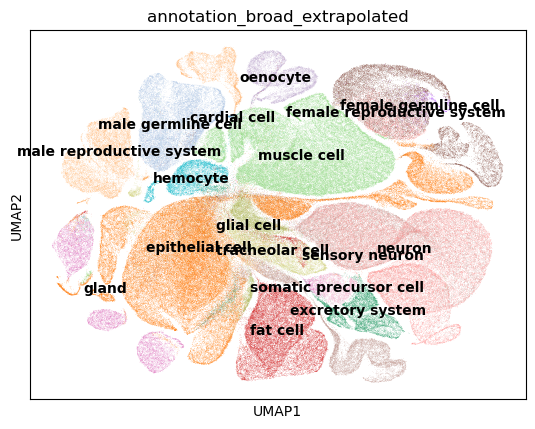

In [ ]:
import scanpy as sc

adata_filtered.obsm["X_vae"] = vae_emb

sc.pp.neighbors(adata_filtered, use_rep="X_vae")
sc.tl.umap(adata_filtered)

sc.pl.umap(
    adata_filtered,
    color=["annotation_broad_extrapolated"],
    legend_loc="on data"
)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Adapter(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )

    def forward(self, x):
        return self.net(x)

class CellCLIP(nn.Module):
    def __init__(self, cell_dim, text_dim, projection_dim=2048):
        super().__init__()

        self.cell_adapter = Adapter(
            in_dim=cell_dim,
            hidden_dim=projection_dim,
            out_dim=projection_dim
        )

        self.text_adapter = Adapter(
            in_dim=text_dim,
            hidden_dim=projection_dim,
            out_dim=projection_dim
        )

        self.logit_scale = nn.Parameter(
            torch.ones([]) * torch.log(torch.tensor(1 / 0.07))
        )

    def forward(self, cell_emb, text_emb):
        cell_features = self.cell_adapter(cell_emb)
        text_features = self.text_adapter(text_emb)

        cell_features = F.normalize(cell_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        return cell_features, text_features

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

# Stratified split by cell type (maintain proportions)
indices = np.arange(len(adata_filtered))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.05,  # 5% holdout
    stratify=adata_filtered.obs['annotation'],
    random_state=42
)

# Save splits
adata_filtered.obs['split'] = 'train'
adata_filtered.obs.loc[adata_filtered.obs.index[test_idx], 'split'] = 'test'

# Extract embeddings
train_cell_emb = vae_emb[train_idx]
train_text_emb = text_emb[train_idx]
test_cell_emb = vae_emb[test_idx]
test_text_emb = text_emb[test_idx]

cell_dim = vae_emb.shape[1]
text_dim = text_emb.shape[1]
print(cell_dim, text_dim)
model = CellCLIP(cell_dim, text_dim)

64 768


In [ ]:
from torch.utils.data import Dataset, DataLoader

class CellTextDataset(Dataset):
    def __init__(self, cell_emb, text_emb):
        self.cell_emb = torch.FloatTensor(cell_emb)
        self.text_emb = torch.FloatTensor(text_emb)
        
    def __len__(self):
        return len(self.cell_emb)
    
    def __getitem__(self, idx):
        return self.cell_emb[idx], self.text_emb[idx]

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

# Dataset class
class CellTextDataset(Dataset):
    def __init__(self, cell_emb, text_emb):
        self.cell_emb = torch.FloatTensor(cell_emb)
        self.text_emb = torch.FloatTensor(text_emb)
        
    def __len__(self):
        return len(self.cell_emb)
    
    def __getitem__(self, idx):
        return self.cell_emb[idx], self.text_emb[idx]

train_cell_emb = vae_emb[train_idx]
test_cell_emb = vae_emb[test_idx]

# Create dataloaders
train_dataset = CellTextDataset(train_cell_emb, train_text_emb)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)

test_dataset = CellTextDataset(test_cell_emb, test_text_emb)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
def clip_loss(similarity_matrix):
    """
    similarity_matrix: Tensor of shape (B, B)
    Entry (i, j) is similarity between cell i and text j
    """
    batch_size = similarity_matrix.size(0)
    device = similarity_matrix.device

    # Ground truth: diagonal alignment
    labels = torch.arange(batch_size, device=device)

    # Cell → text
    loss_c2t = F.cross_entropy(similarity_matrix, labels)

    # Text → cell
    loss_t2c = F.cross_entropy(similarity_matrix.T, labels)

    return (loss_c2t + loss_t2c) / 2

def train_epoch(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    
    for cell_emb, text_emb in tqdm(train_loader, desc="Training"):
        optimizer.zero_grad()
        
        # Forward pass
        cell_features, text_features = model(cell_emb, text_emb)
        
        # Compute similarity matrix
        logit_scale = model.logit_scale.exp()
        similarity_matrix = (cell_features @ text_features.T) * logit_scale
        
        # CLIP loss
        loss = clip_loss(similarity_matrix)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            model.logit_scale.clamp_(
                min=torch.log(torch.tensor(1/100, device=model.logit_scale.device)),
                max=torch.log(torch.tensor(100.0, device=model.logit_scale.device))
            )
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate(model, test_loader, recall_k=5):
    model.eval()

    total_loss = 0.0
    total_pos = 0.0
    total_neg = 0.0
    total_gap = 0.0
    cell_recall = 0
    total_samples = 0
    text_recall = 0

    with torch.no_grad():
        for cell_emb, text_emb in test_loader:
            cell_features, text_features = model(cell_emb, text_emb)

            logit_scale = model.logit_scale.exp()
            sim = (cell_features @ text_features.T) * logit_scale

            # InfoNCE loss
            loss = clip_loss(sim)
            total_loss += loss.item()

            batch_size = sim.size(0)
            total_samples += batch_size

            # Positive similarities (diagonal)
            pos = sim.diag()
            total_pos += pos.mean().item()

            # Negative similarities (row-wise mean excluding diagonal)
            neg = (sim.sum(dim=1) - pos) / (batch_size - 1)
            total_neg += neg.mean().item()

            # Gap diagnostic
            total_gap += (pos - neg).mean().item()

            # Recall@K cell
            topk = sim.topk(recall_k, dim=1).indices
            labels = torch.arange(batch_size, device=sim.device).unsqueeze(1)
            cell_recall += (topk == labels).any(dim=1).sum().item()

            # Recall@K text
            topk_text = sim.topk(recall_k, dim=0).indices
            labels = torch.arange(batch_size, device=sim.device).unsqueeze(0)
            text_recall = (topk_text == labels).any(dim=0).float().mean()
    
    avg_loss = total_loss / len(test_loader)
    avg_pos = total_pos / len(test_loader)
    avg_neg = total_neg / len(test_loader)
    avg_gap = total_gap / len(test_loader)
    cell_recall_at_k = cell_recall / total_samples
    text_recall_at_k = text_recall / total_samples
    
    return {
        "loss": avg_loss,
        "pos_sim": avg_pos,
        "neg_sim": avg_neg,
        "gap": avg_gap,
        f"cell_recall@{recall_k}": cell_recall_at_k,
        f"text_recall@{recall_k}": text_recall_at_k
    }

In [ ]:
num_epochs = 15
best_test_loss = float('inf')
history = {
    'train_loss': [],
    'test_loss': [],
    'pos_sim': [],
    'neg_sim': [],
    'gap': [],
    'cell_recall@5': [],
    'text_recall@5': []
}

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer)
    
    # Evaluate
    metrics = evaluate(model, test_loader, recall_k=5)
    
    # Update scheduler
    scheduler.step()
    
    # Track history
    history['train_loss'].append(train_loss)
    history['test_loss'].append(metrics['loss'])
    history['pos_sim'].append(metrics['pos_sim'])
    history['neg_sim'].append(metrics['neg_sim'])
    history['gap'].append(metrics['gap'])
    history['text_recall@5'].append(metrics['text_recall@5'])
    history['cell_recall@5'].append(metrics['cell_recall@5'])
    
    # Print progress
    print(
        f"Epoch {epoch+1:03d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {metrics['loss']:.4f} | "
        f"Gap: {metrics['gap']:.3f} | "
        f"R@5: {metrics['text_recall@5']:.3f} | "
        f"R@5: {metrics['cell_recall@5']:.3f} | "
        f"LR: {scheduler.get_last_lr()[0]:.2e}"
    )
    
    # Save best model
    if metrics['loss'] < best_test_loss:
        best_test_loss = metrics['loss']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics':metrics
        }, 'vae_clip_model.pt')
        print(f"  ✓ Saved best model (test loss: {metrics['loss']:.4f})")

print("\n" + "="*60)
print("Training complete!")
print(f"Best test loss: {best_test_loss:.4f}")
print("="*60)

Training: 100%|██████████████████████████████| 717/717 [01:17<00:00,  9.26it/s]


Epoch 001/15 | Train Loss: 3.7393 | Test Loss: 3.3834 | Gap: 6.503 | R@5: 0.000 | R@5: 0.385 | LR: 9.99e-06
  ✓ Saved best model (test loss: 3.3834)


Training: 100%|██████████████████████████████| 717/717 [01:16<00:00,  9.36it/s]


Epoch 002/15 | Train Loss: 3.3205 | Test Loss: 3.2485 | Gap: 6.901 | R@5: 0.000 | R@5: 0.407 | LR: 9.96e-06
  ✓ Saved best model (test loss: 3.2485)


Training: 100%|██████████████████████████████| 717/717 [01:16<00:00,  9.37it/s]


...

Epoch 013/15 | Train Loss: 3.0784 | Test Loss: 3.0609 | Gap: 7.794 | R@5: 0.000 | R@5: 0.451 | LR: 8.42e-06
  ✓ Saved best model (test loss: 3.0609)


Training: 100%|██████████████████████████████| 717/717 [01:21<00:00,  8.77it/s]


Epoch 014/15 | Train Loss: 3.0726 | Test Loss: 3.0567 | Gap: 7.932 | R@5: 0.000 | R@5: 0.451 | LR: 8.19e-06
  ✓ Saved best model (test loss: 3.0567)


Training: 100%|██████████████████████████████| 717/717 [01:21<00:00,  8.82it/s]


Epoch 015/15 | Train Loss: 3.0676 | Test Loss: 3.0575 | Gap: 7.916 | R@5: 0.000 | R@5: 0.450 | LR: 7.94e-06

Training complete!
Best test loss: 3.0567


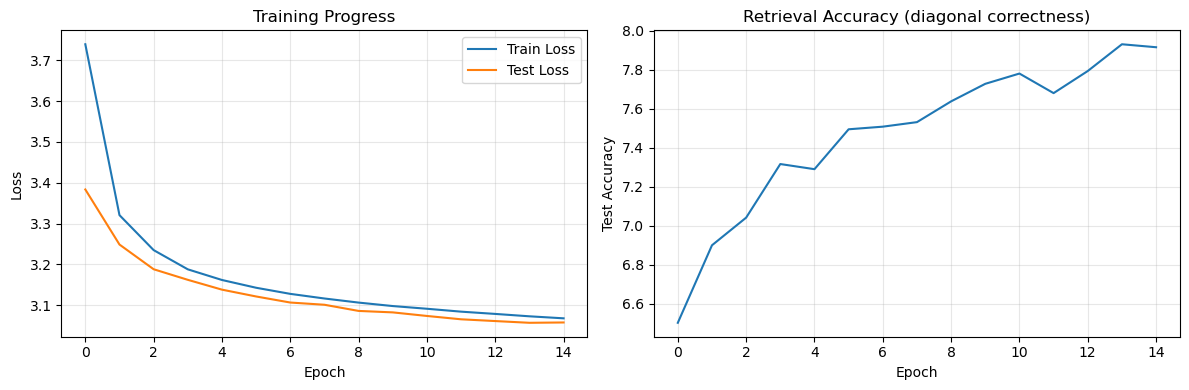

Final test accuracy: 7.916


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Progress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['gap'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Retrieval Accuracy (diagonal correctness)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Final test accuracy: {history['gap'][-1]:.3f}")

In [ ]:
# Load best model
checkpoint = torch.load('vae_clip_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")

# Quick sanity checks
print("\n" + "="*60)
print("ZERO-SHOT QUERIES")
print("="*60)

# Simple cell type queries
queries = [
    "neuron",
    "muscle",
    "gland"
]

# For each query, see what cell types rank highest
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
biobert = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
biobert.eval()

for query_text in queries:
    # Encode query
    inputs = tokenizer(query_text, return_tensors="pt", max_length=128, truncation=True)
    with torch.no_grad():
        outputs = biobert(**inputs)
        query_emb = outputs.last_hidden_state[:, 0, :]
        query_features = model.text_adapter(query_emb)
        query_features = F.normalize(query_features, dim=-1)
    
    # Compare to test cells
    test_cell_torch = torch.FloatTensor(test_cell_emb)
    with torch.no_grad():
        cell_features = model.cell_adapter(test_cell_torch)
        cell_features = F.normalize(cell_features, dim=-1)
    
    # Compute similarities
    similarities = (cell_features @ query_features.T).squeeze().numpy()
    
    # Get top 100 cells
    top_100_idx = np.argsort(similarities)[-100:][::-1]
    top_cell_types = adata_filtered.obs.iloc[test_idx[top_100_idx]]['annotation'].value_counts()
    
    print(f"\nQuery: '{query_text}'")
    print(f"Top cell types in top-100:")
    print(top_cell_types.head())
    print(f"Similarity range: [{similarities.min():.3f}, {similarities.max():.3f}]")

✓ Loaded best model from epoch 14

ZERO-SHOT QUERIES


/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Query: 'neuron'
Top cell types in top-100:
annotation
adult ventral nervous system       32
adult peripheral nervous system    16
Johnston organ neuron              11
Kenyon cell                         3
dopaminergic PAM neuron             3
Name: count, dtype: int64
Similarity range: [-0.337, 0.398]

Query: 'muscle'
Top cell types in top-100:
annotation
muscle cell                                45
skeletal muscle of head                    18
indirect flight muscle                     12
adult heart ventral longitudinal muscle     6
ovarian sheath muscle                       5
Name: count, dtype: int64
Similarity range: [-0.196, 0.210]

Query: 'gland'
Top cell types in top-100:
annotation
early elongation stage spermatid                   23
enterocyte of posterior adult midgut epithelium    15
adult differentiating enterocyte                    8
spermatocyte 0                                      7
adult midgut enterocyte                             7
Name: count, dtype: int64


In [ ]:
def query_cells(model, query_text, adata, expression_emb, return_scores=True):
    """
    Query cells with natural language
    
    Parameters:
    -----------
    model : trained CellCLIP model
    query_text : str, e.g., "cells involved in inter-brain communication"
    adata : AnnData with cell metadata
    expression_emb : cell expression embeddings (PCA)
    
    Returns:
    --------
    similarities : array of similarity scores for each cell
    """
    model.eval()
    
    # Encode query text with BioBERT
    tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    biobert = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    biobert.eval()
    
    inputs = tokenizer(query_text, return_tensors="pt", max_length=128, truncation=True)
    with torch.no_grad():
        outputs = biobert(**inputs)
        query_emb = outputs.last_hidden_state[:, 0, :].numpy()  # [CLS] token
    
    # Project query to CLIP space
    query_emb_torch = torch.FloatTensor(query_emb)
    with torch.no_grad():
        query_features = model.text_adapter(query_emb_torch)
        query_features = F.normalize(query_features, dim=-1)
    
    # Project all cells to CLIP space
    cell_emb_torch = torch.FloatTensor(expression_emb)
    with torch.no_grad():
        cell_features = model.cell_adapter(cell_emb_torch)
        cell_features = F.normalize(cell_features, dim=-1)
    
    # Compute similarities (cosine similarity in CLIP space)
    similarities = (cell_features @ query_features.T).squeeze().numpy()
    
    return similarities


def visualize_query(model, query_text, adata, expression_emb, coords=None):
    """
    Visualize query results on tSNE
    """
    import matplotlib.pyplot as plt
    
    # Get similarities
    similarities = query_cells(model, query_text, adata, expression_emb)
    
    # Plot on tSNE
    if coords is None:
        # Use existing UMAP or compute
        coords = adata.obsm['X_tsne']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: major cell types
    for ct in adata.obs['annotation_broad_extrapolated'].unique():
        mask = adata.obs['annotation_broad_extrapolated'] == ct
        axes[0].scatter(coords[mask, 0], coords[mask, 1],
                       s=1, alpha=0.5, label=ct)
    axes[0].set_title('Major Cell Types')
    axes[0].legend(markerscale=5)
    
    # Right: query similarity
    scatter = axes[1].scatter(coords[:, 0], coords[:, 1],
                             c=similarities, s=1, alpha=0.7,
                             cmap='viridis', vmin=np.percentile(similarities, 5),
                             vmax=np.percentile(similarities, 95))
    axes[1].set_title(f"Query: '{query_text}'")
    plt.colorbar(scatter, ax=axes[1], label='Similarity Score')
    
    plt.tight_layout()
    plt.show()
    
    # Print top cells
    top_idx = np.argsort(similarities)[-20:][::-1]
    print(f"\nTop 20 cells for query: '{query_text}'")
    print(adata_filtered.obs.iloc[top_idx][['annotation_broad_extrapolated', 'annotation']].value_counts())
    
    return similarities

/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


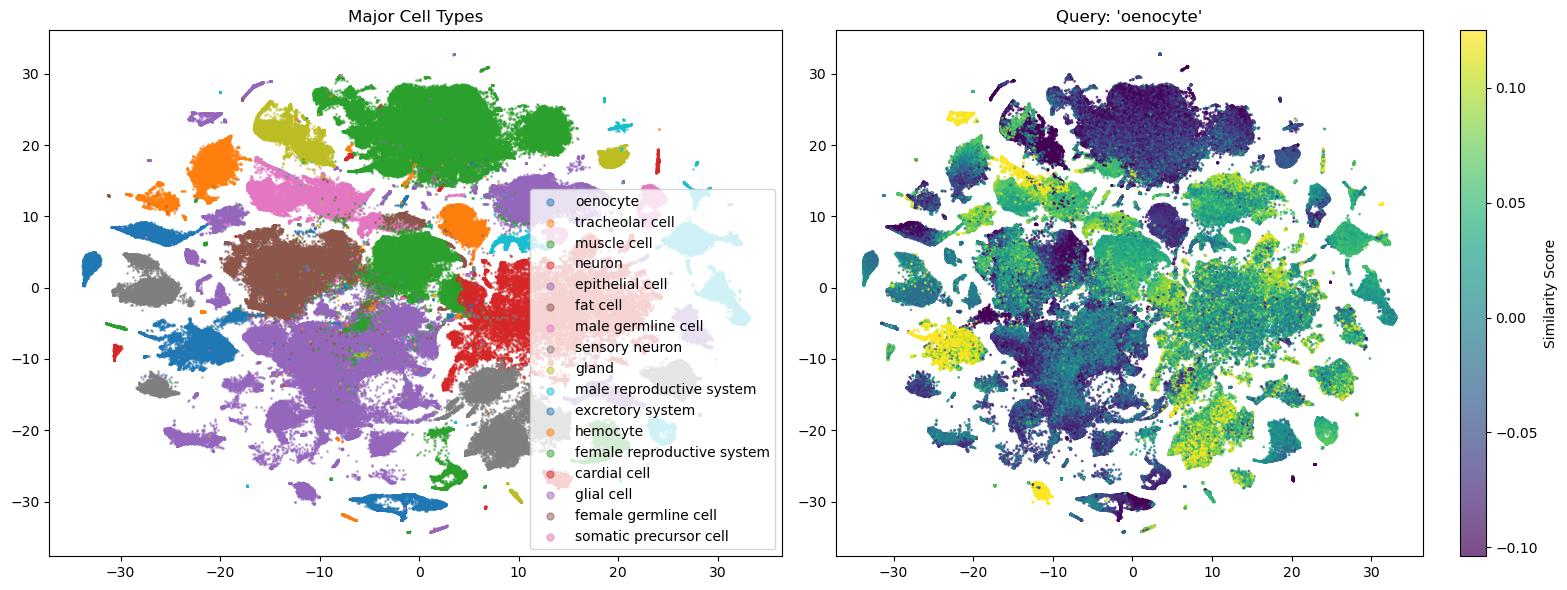


Top 20 cells for query: 'oenocyte'
annotation_broad_extrapolated  annotation                
oenocyte                       epithelial cell               6
muscle cell                    skeletal muscle of head       3
neuron                         columnar neuron T1            2
                               lamina monopolar neuron L1    2
sensory neuron                 Johnston organ neuron         2
epithelial cell                cardia (2)                    1
                               epithelial cell               1
male germline cell             epithelial cell               1
sensory neuron                 auditory sensory neuron       1
                               olfactory receptor neuron     1
Name: count, dtype: int64
Similarity range: [-0.196, 0.221]



/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


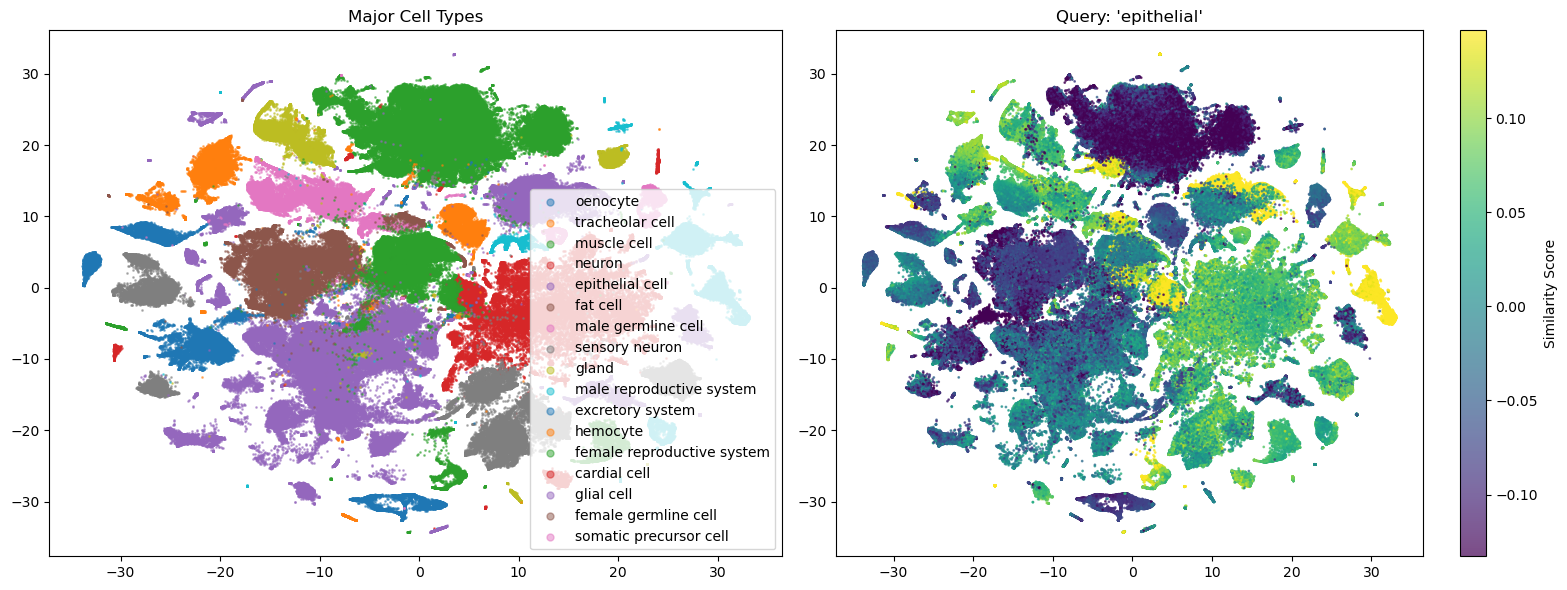


Top 20 cells for query: 'epithelial'
annotation_broad_extrapolated  annotation                                 
epithelial cell                main body follicle cell ca. until St. 5        13
                               oviduct                                         2
male reproductive system       escort cell                                     2
epithelial cell                artefact                                        1
                               central main body follicle cell ca. St. 6-8     1
female reproductive system     artefact                                        1
Name: count, dtype: int64
Similarity range: [-0.283, 0.261]



/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


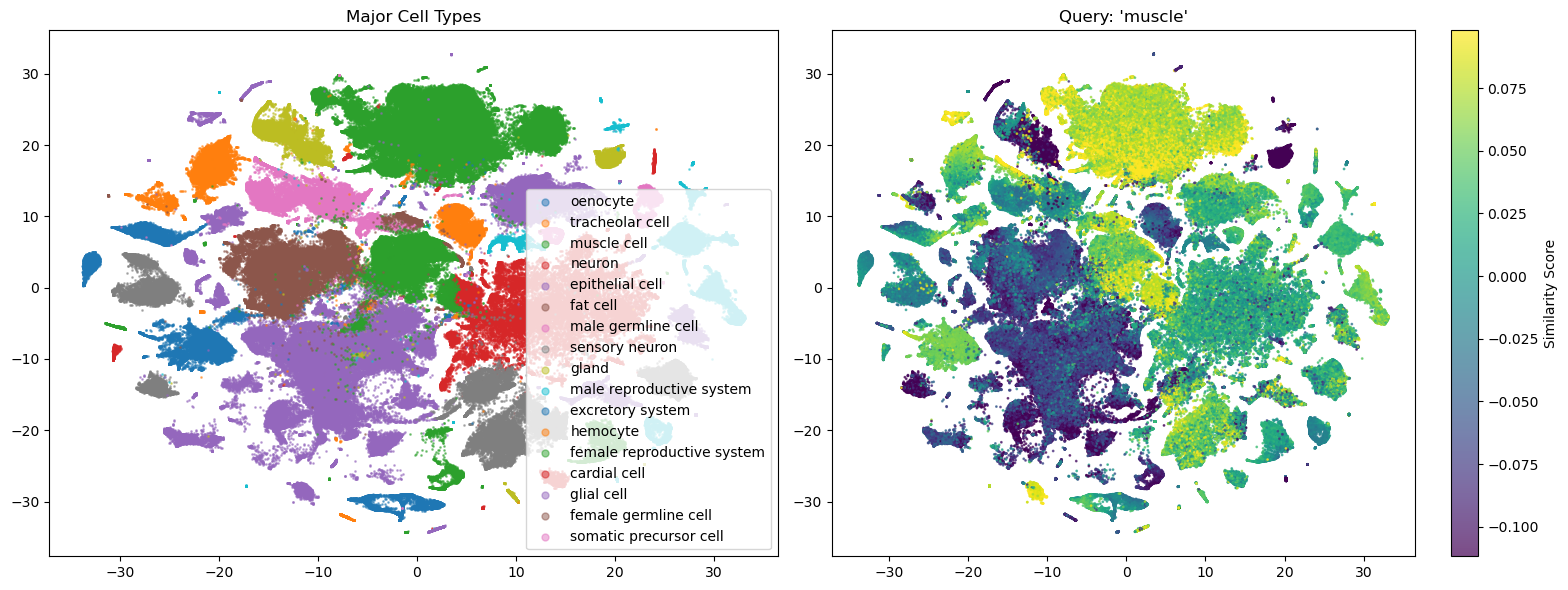


Top 20 cells for query: 'muscle'
annotation_broad_extrapolated  annotation                             
muscle cell                    muscle cell                                5
hemocyte                       hemocyte                                   3
neuron                         ovary cell                                 3
muscle cell                    male reproductive tract muscle             2
female reproductive system     muscle cell                                1
hemocyte                       adult alary muscle                         1
                               adult heart ventral longitudinal muscle    1
                               adult ostium                               1
male germline cell             ovary cell                                 1
muscle cell                    adult heart ventral longitudinal muscle    1
                               hemocyte                                   1
Name: count, dtype: int64
Similarity range: [-0.200, 0.230]

/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


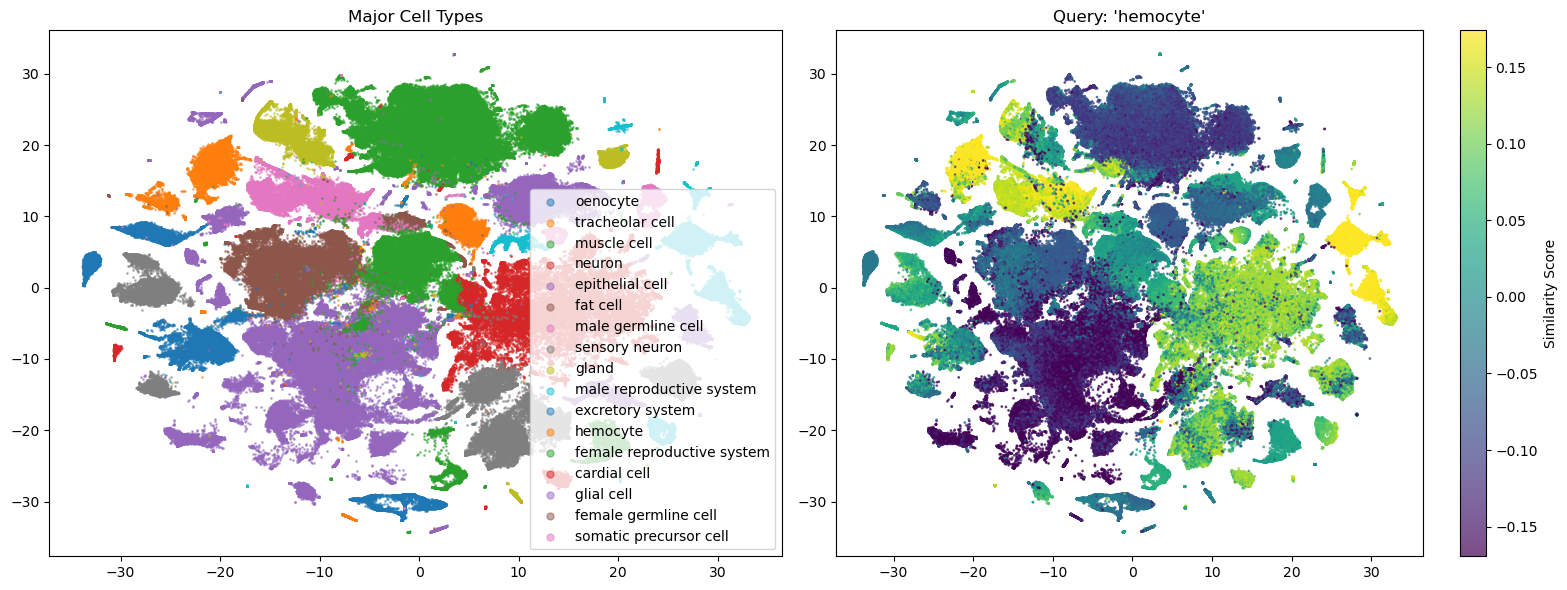


Top 20 cells for query: 'hemocyte'
annotation_broad_extrapolated  annotation
hemocyte                       hemocyte      20
Name: count, dtype: int64
Similarity range: [-0.251, 0.269]



/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


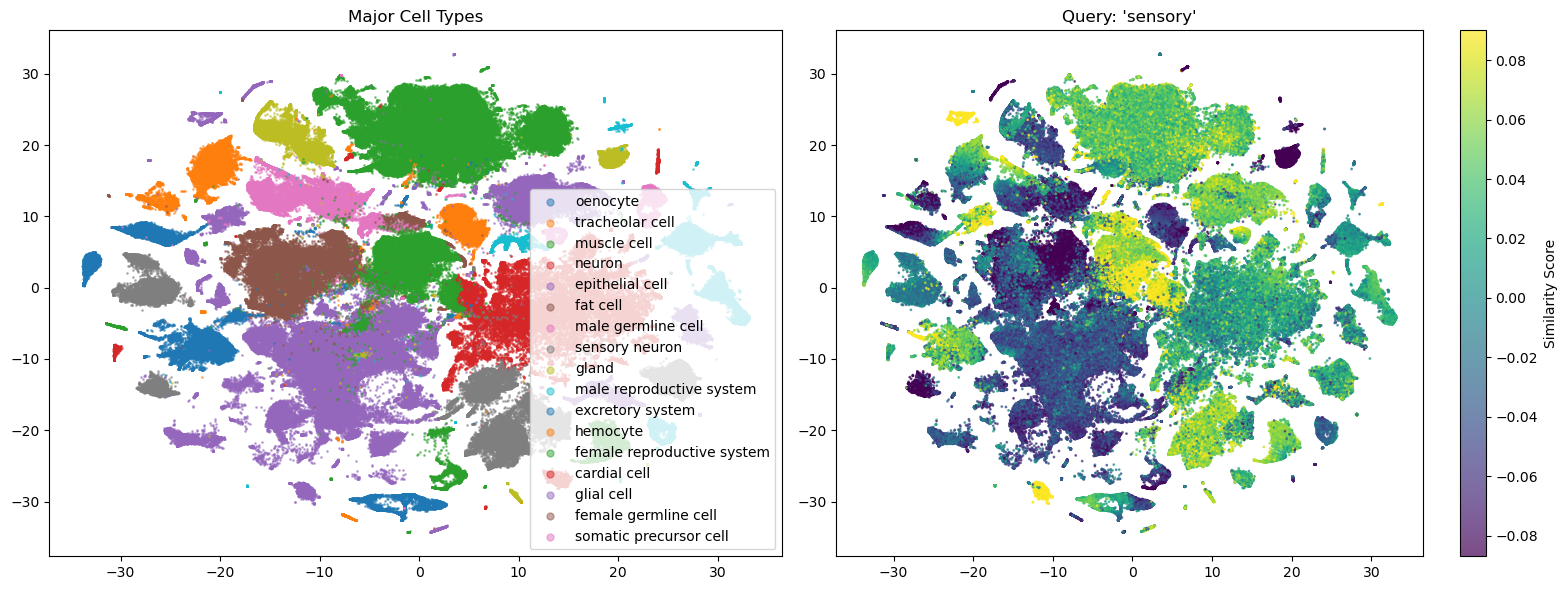


Top 20 cells for query: 'sensory'
annotation_broad_extrapolated  annotation                                           
muscle cell                    muscle cell                                              5
cardial cell                   cardiomyocyte, working adult heart muscle (non-ostia)    2
female reproductive system     muscle cell                                              2
muscle cell                    indirect flight muscle                                   2
oenocyte                       epithelial cell                                          2
female reproductive system     artefact                                                 1
                               epithelial cell                                          1
                               germline cell                                            1
                               ovary cell                                               1
gland                          male accessory gland                   

/Users/dickinsonia/miniconda3/envs/biobert/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


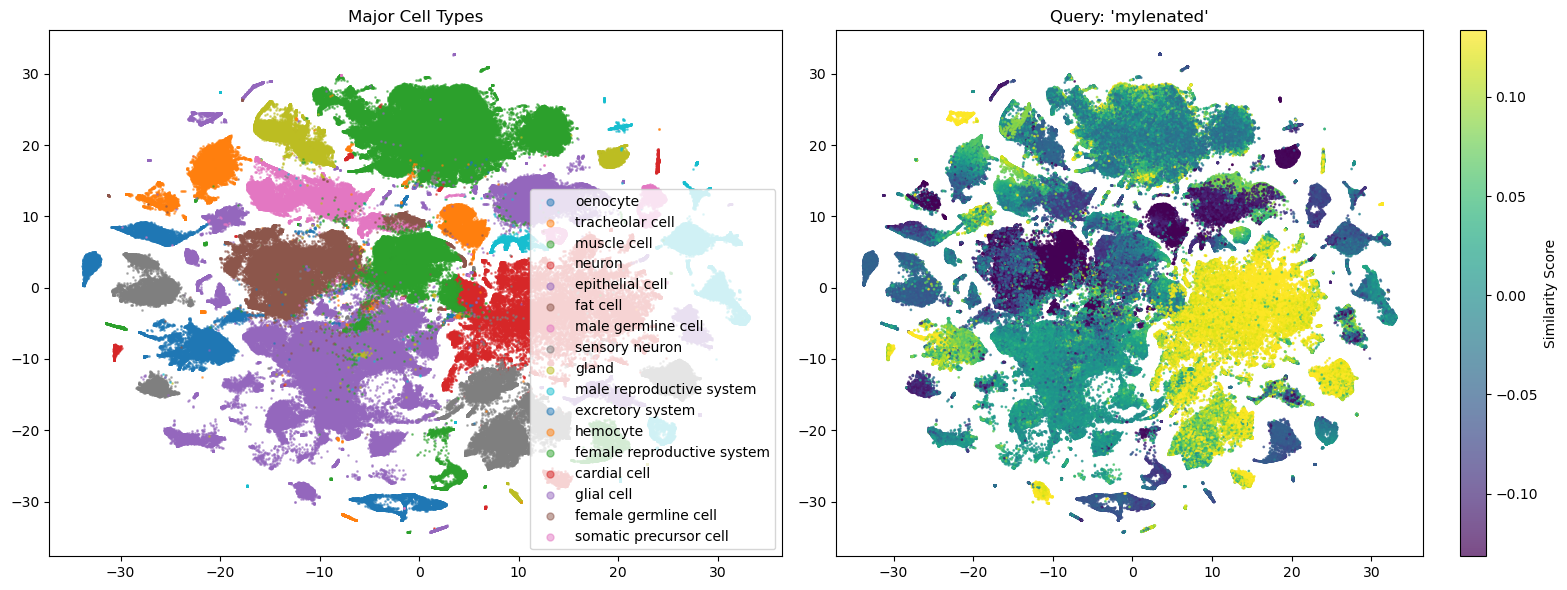


Top 20 cells for query: 'mylenated'
annotation_broad_extrapolated  annotation                                           
oenocyte                       epithelial cell                                          17
cardial cell                   cardiomyocyte, working adult heart muscle (non-ostia)     1
oenocyte                       adult Malpighian tubule                                   1
                               adult salivary gland                                      1
Name: count, dtype: int64
Similarity range: [-0.210, 0.239]


In [ ]:
queries = [
    "oenocyte",
    "epithelial",
    "muscle",
    "hemocyte",
    "sensory",
    "mylenated"
]

for query in queries:
    print(f"\n{'='*60}")
    similarities = visualize_query(model, query, adata_filtered, vae_emb)
    print(f"Similarity range: [{similarities.min():.3f}, {similarities.max():.3f}]")

In [ ]:
afca = sc.read_h5ad("adata_headBody_S_v1.0.h5ad")

NameError: name 'sc' is not defined

In [ ]:
afca

NameError: name 'afca' is not defined

In [ ]:
print(f"Sex table:\n{afca.obs['sex'].value_counts()}")
print(f"Age table:\n{afca.obs['age'].value_counts()}")
print(f"Age table:\n{afca.obs['afca_annotation_broad'].value_counts()}")
print(f"Age table:\n{afca.obs['dataset'].value_counts()}")
print(f"Age table:\n{afca.obs['afca_annotation'].value_counts()}")

afca.obs

Sex table:
sex
female    293506
male      264396
mix         8352
Name: count, dtype: int64
Age table:
age
5     196905
30    146304
50    118795
70    104250
Name: count, dtype: int64
Age table:
afca_annotation_broad
CNS neuron                    194086
epithelial cell                88910
muscle cell                    85514
sensory neuron                 59368
glial cell                     37448
fat cell                       36501
female reproductive system     29219
tracheal cell                   7317
oenocyte                        5939
female germline cell            5260
somatic precursor cell          4733
hemocyte                        4379
gland                           4119
male reproductive system        2471
male germline cell               629
excretory system                 325
cardial cell                      36
Name: count, dtype: int64
Age table:
dataset
AFCA    369349
FCA     196905
Name: count, dtype: int64
Age table:
afca_annotation
unannotated              

,tissue,sex,age,sex_age,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,log1p_n_genes_by_counts,log1p_total_counts,log1p_total_counts_mt,dataset,fca_annotation,afca_annotation,afca_annotation_broad
AAACCCAAGGATACAT-1_AFCA_female_body_30_S1,body,female,30,female_30,334,515.0,2.0,0.388350,5.814131,6.246107,1.098612,AFCA,nan,follicle cell,female reproductive system
AAACCCAGTGCAATAA-1_AFCA_female_body_30_S1,body,female,30,female_30,892,2425.0,0.0,0.000000,6.794587,7.793999,0.000000,AFCA,nan,adult fat body_body,fat cell
AAACCCATCCGATGTA-1_AFCA_female_body_30_S1,body,female,30,female_30,629,1367.0,0.0,0.000000,6.445720,7.221105,0.000000,AFCA,nan,adult fat body_body,fat cell
AAACCCATCGTGGGTC-1_AFCA_female_body_30_S1,body,female,30,female_30,479,863.0,1.0,0.115875,6.173786,6.761573,0.693147,AFCA,nan,adult fat body_body,fat cell
AAACGAAAGGAGTCTG-1_AFCA_female_body_30_S1,body,female,30,female_30,605,1345.0,1.0,0.074349,6.406880,7.204893,0.693147,AFCA,nan,follicle cell,female reproductive system
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTACGAAAT-f7ed0992__FCA15_Female_head_adult,head,female,5,female_5,334,535.0,1.0,0.186916,5.814131,6.284134,0.693147,FCA,epithelial cell,epithelial cell_head,epithelial cell
TTTGTTGCAACGCATT-f7ed0992__FCA15_Female_head_adult,head,female,5,female_5,443,785.0,3.0,0.382166,6.095825,6.666957,1.386294,FCA,ensheathing glial cell,ensheathing glial cell,glial cell
TTTGTTGTCATCGCCT-f7ed0992__FCA15_Female_head_adult,head,female,5,female_5,388,660.0,0.0,0.000000,5.963579,6.493754,0.000000,FCA,cone cell,epithelial cell_head,epithelial cell
TTTGTTGTCCATTCGC-f7ed0992__FCA15_Female_head_adult,head,female,5,female_5,1092,3170.0,19.0,0.599369,6.996681,8.061802,2.995732,FCA,unannotated,outer photoreceptor cell,sensory neuron


In [ ]:
!pip install transformers

In [ ]:
import os
print(os.getcwd())
print([f for f in os.listdir('.') if f.endswith('.h5ad')])

/Users/laurenpearson/Downloads
['adata_headBody_S_v1.0 (1).h5ad', 'heart.h5ad', 'adata_headBody_S_v1.0.h5ad']


In [ ]:
import scanpy as sc
adata = sc.read_h5ad("adata_headBody_S_v1.0.h5ad")
print(adata.obs.columns.tolist())
print(adata.shape)

['tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad']
(566254, 15992)


In [ ]:
adata.obs['dataset'].value_counts()

dataset
AFCA    369349
FCA     196905
Name: count, dtype: int64

In [ ]:
sc.pl.tsne(afca, color="afca_annotation_broad")

NameError: name 'afca' is not defined

In [ ]:
import scanpy as sc

# Self-contained: doesn't depend on earlier cells having been run in this session
if 'X_pca' in adata_filtered.obsm:
    print("Using existing PCA embeddings")
    expression_emb = adata_filtered.obsm['X_pca'][:, :50]
else:
    print("Computing PCA with 50 components...")
    sc.pp.pca(adata_filtered, n_comps=50)
    expression_emb = adata_filtered.obsm['X_pca']

print("expression_emb shape:", expression_emb.shape)

NameError: name 'adata_filtered' is not defined

In [ ]:
pip install scib-metrics

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 MB 10.1 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.8/566.8 kB 23.3 MB/s  0:00:00
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [scib-metrics] [chex]able]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import scanpy as sc

if 'X_pca' in adata_filtered.obsm:
    print("Using existing PCA embeddings")
    expression_emb = adata_filtered.obsm['X_pca'][:, :50]
else:
    print("Computing PCA with 50 components...")
    sc.pp.pca(adata_filtered, n_comps=50)
    expression_emb = adata_filtered.obsm['X_pca']

print("expression_emb shape:", expression_emb.shape)

NameError: name 'adata_filtered' is not defined

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch 
import torch.nn as nn
import torch.nn.functional as F

adata = sc.read_h5ad("adata_headBody_S_v1.0.h5ad")  

# ^ to hopefully load any ofthe fresh FCA data 

adata_filtered = adata[
    (adata.obs["sex"].isin(['male', "female"])) &
    (adata.obs["annotation"] != "unannotated")
].copy()

print("adata:", adata.shape)
print("adata_filtered:", adata_filtered.shape)
print("loading success")



KeyError: 'annotation'

In [ ]:
print(adata.obs.columns.tolist())

['tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad']


In [ ]:
print(adata.obs.head())

                                          tissue     sex age    sex_age  \
AAACCCAAGGATACAT-1_AFCA_female_body_30_S1   body  female  30  female_30   
AAACCCAGTGCAATAA-1_AFCA_female_body_30_S1   body  female  30  female_30   
AAACCCATCCGATGTA-1_AFCA_female_body_30_S1   body  female  30  female_30   
AAACCCATCGTGGGTC-1_AFCA_female_body_30_S1   body  female  30  female_30   
AAACGAAAGGAGTCTG-1_AFCA_female_body_30_S1   body  female  30  female_30   

                                           n_genes_by_counts  total_counts  \
AAACCCAAGGATACAT-1_AFCA_female_body_30_S1                334         515.0   
AAACCCAGTGCAATAA-1_AFCA_female_body_30_S1                892        2425.0   
AAACCCATCCGATGTA-1_AFCA_female_body_30_S1                629        1367.0   
AAACCCATCGTGGGTC-1_AFCA_female_body_30_S1                479         863.0   
AAACGAAAGGAGTCTG-1_AFCA_female_body_30_S1                605        1345.0   

                                           total_counts_mt  pct_counts_mt  \
AAA

In [ ]:
adata_filtered = adata.copy()

print("adata:", adata.shape)
print("adata_filtered:", adata_filtered.shape)

adata: (566254, 15992)
adata_filtered: (566254, 15992)


In [ ]:
print("\nMetadata columns:")
print(adata_filtered.obs.columns.tolist())


Metadata columns:
['tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad']


In [ ]:
adata.obs["afca_annotation"]

AAACCCAAGGATACAT-1_AFCA_female_body_30_S1                          follicle cell
AAACCCAGTGCAATAA-1_AFCA_female_body_30_S1                    adult fat body_body
AAACCCATCCGATGTA-1_AFCA_female_body_30_S1                    adult fat body_body
AAACCCATCGTGGGTC-1_AFCA_female_body_30_S1                    adult fat body_body
AAACGAAAGGAGTCTG-1_AFCA_female_body_30_S1                          follicle cell
                                                                 ...            
TTTGGTTGTACGAAAT-f7ed0992__FCA15_Female_head_adult          epithelial cell_head
TTTGTTGCAACGCATT-f7ed0992__FCA15_Female_head_adult        ensheathing glial cell
TTTGTTGTCATCGCCT-f7ed0992__FCA15_Female_head_adult          epithelial cell_head
TTTGTTGTCCATTCGC-f7ed0992__FCA15_Female_head_adult      outer photoreceptor cell
TTTGTTGTCGCTTGCT-f7ed0992__FCA15_Female_head_adult    lamina monopolar neuron L1
Name: afca_annotation, Length: 566254, dtype: category
Categories (163, object): ['16-cell germline cyst in g

In [ ]:
adata_filtered = adata[
    (adata.obs["sex"].isin(["male", "female"])) &
    (adata.obs["afca_annotation"].notna())
].copy()

print("Original shape:", adata.shape)
print("Filtered shape:", adata_filtered.shape)

Original shape: (566254, 15992)
Filtered shape: (557902, 15992)


In [ ]:
print("\nBroad cell types:")
print(adata_filtered.obs["afca_annotation_broad"].value_counts().head(20))

print("\nFine cell types:")
print(adata_filtered.obs["afca_annotation"].value_counts().head(20))


Broad cell types:
afca_annotation_broad
CNS neuron                    190949
epithelial cell                87084
muscle cell                    84303
sensory neuron                 58745
glial cell                     36920
fat cell                       36417
female reproductive system     28636
tracheal cell                   7290
oenocyte                        5927
female germline cell            5199
somatic precursor cell          4689
hemocyte                        4302
gland                           4084
male reproductive system        2430
male germline cell               582
excretory system                 309
cardial cell                      36
Name: count, dtype: int64

Fine cell types:
afca_annotation
unannotated                           113199
muscle cell                            53895
epithelial cell_body                   42978
adult fat body_body                    31311
follicle cell                          25251
adult ventral nervous system           22172


In [ ]:
print("\nDatasets:")
print(adata_filtered.obs["dataset"].value_counts())


Datasets:
dataset
AFCA    369349
FCA     188553
Name: count, dtype: int64


In [ ]:
print(
    pd.crosstab(
        adata_filtered.obs["dataset"],
        adata_filtered.obs["afca_annotation_broad"]
    )
)

afca_annotation_broad  CNS neuron  cardial cell  epithelial cell  \
dataset                                                            
AFCA                       117653            27            56690   
FCA                         73296             9            30394   

afca_annotation_broad  excretory system  fat cell  female germline cell  \
dataset                                                                   
AFCA                                247     33307                  2391   
FCA                                  62      3110                  2808   

afca_annotation_broad  female reproductive system  gland  glial cell  \
dataset                                                                
AFCA                                        20138   3522       26145   
FCA                                          8498    562       10775   

afca_annotation_broad  hemocyte  male germline cell  male reproductive system  \
dataset                                                 

 every broad cell type occurs in both AFCA and FCA but big imbalance btwn dataset sizes AFCA (larger and FCA smaller shown across all cell types)

In [ ]:
print(
    pd.crosstab(
        adata_filtered.obs["dataset"],
        adata_filtered.obs["tissue"]
    )
)

tissue     body    head
dataset                
AFCA     179679  189670
FCA       92249   96304


In [ ]:
print("\nNumber of tissues:")
print(adata_filtered.obs["tissue"].nunique())

print("\nCells per tissue:")
print(adata_filtered.obs["tissue"].value_counts())


Number of tissues:
2

Cells per tissue:
tissue
head    285974
body    271928
Name: count, dtype: int64


In [ ]:
import os

for file in os.listdir("."):
    if file.endswith((".npy", ".pt", ".h5ad", ".pth")):
        print(file)

adata_headBody_S_v1.0 (1).h5ad
heart.h5ad
adata_headBody_S_v1.0.h5ad


In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = sc.read_h5ad("adata_headBody_S_v1.0.h5ad")

print(adata)
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 566254 × 15992
    obs: 'tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'age_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'sex_colors', 'tissue_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
['tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad']


In [ ]:
adata_filtered = adata[
    (adata.obs["sex"].isin(["male", "female"])) &
    (adata.obs["afca_annotation"].notna()) &
    (adata.obs["afca_annotation_broad"].notna())
].copy()

CELL_TYPE_KEY = "afca_annotation_broad"
BATCH_KEY = "dataset"

print("Filtered:", adata_filtered.shape)

Filtered: (557902, 15992)


taking a smaller subset so if it works i can reproduce for the benchmark 

In [ ]:
np.random.seed(42)

n_cells = 20000

idx = np.random.choice(
    adata_filtered.n_obs,
    size=n_cells,
    replace=False
)

adata_bench = adata_filtered[idx].copy()

print(adata_bench)

AnnData object with n_obs × n_vars = 20000 × 15992
    obs: 'tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'age_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'sex_colors', 'tissue_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


now check to see if AFCA and FCA is divided 

In [ ]:
print(adata_bench.obs["dataset"].value_counts())

print(
    pd.crosstab(
        adata_bench.obs["dataset"],
        adata_bench.obs["afca_annotation_broad"]
    )
)

dataset
AFCA    13141
FCA      6859
Name: count, dtype: int64
afca_annotation_broad  CNS neuron  cardial cell  epithelial cell  \
dataset                                                            
AFCA                         4165             3             2000   
FCA                          2695             1             1105   

afca_annotation_broad  excretory system  fat cell  female germline cell  \
dataset                                                                   
AFCA                                 11      1180                    81   
FCA                                   2        95                   112   

afca_annotation_broad  female reproductive system  gland  glial cell  \
dataset                                                                
AFCA                                          751    101         895   
FCA                                           348     21         356   

afca_annotation_broad  hemocyte  male germline cell  male reproductive syst

1st embedding 

In [ ]:
sc.pp.normalize_total(adata_bench, target_sum=1e4)
sc.pp.log1p(adata_bench)

sc.pp.highly_variable_genes(
    adata_bench,
    n_top_genes=2000,
    subset=True
)

sc.pp.scale(adata_bench, max_value=10)

sc.tl.pca(
    adata_bench,
    n_comps=50
)

print(adata_bench.obsm["X_pca"].shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


(20000, 50)


In [ ]:
adata_bench.write_h5ad("fca_benchmark_subset.h5ad")

trying to understand what is being done by the PCA (pre VAE/CLIP runs)

In [ ]:
sc.pp.neighbors(
    adata_bench,
    use_rep="X_pca",
    n_neighbors=15
)

sc.tl.umap(adata_bench)

have umap coloured by cell type

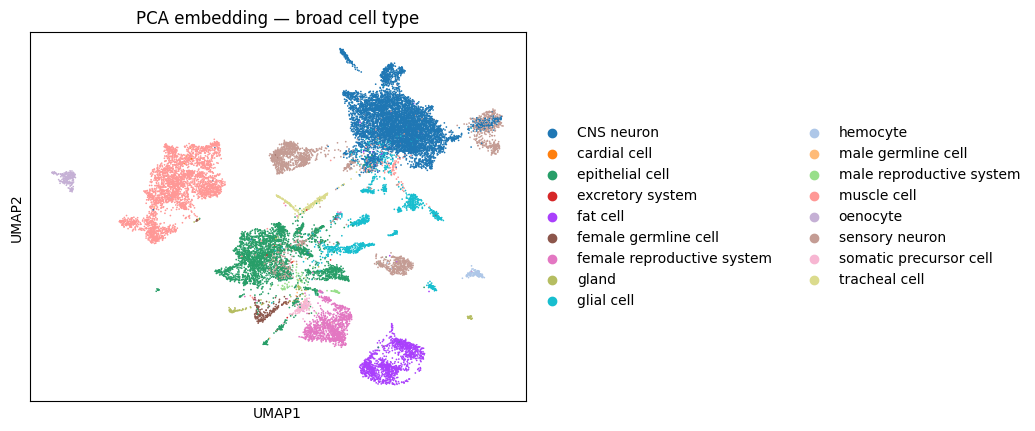

In [ ]:
sc.pl.umap(
    adata_bench,
    color="afca_annotation_broad",
    legend_loc="right margin",
    title="PCA embedding — broad cell type"
)

^ not awful 

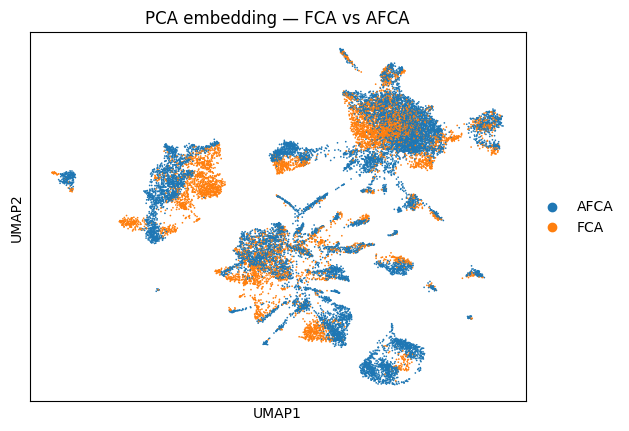

In [ ]:
sc.pl.umap(
    adata_bench,
    color="dataset",
    title="PCA embedding — FCA vs AFCA"
)

^ both datasets share biological regions mainly the CNS neurons and the epithelial cell regions 

In [ ]:
adata_bench.write_h5ad("fca_benchmark_subset_pca.h5ad")

In [ ]:
adata_bench = sc.read_h5ad("fca_benchmark_subset_pca.h5ad")

obvi for the benchmark would not want to just have umap plots divided by dataset group, would it be wrong to assume we would want to maybe have like cell type regions (i.e cns neurons, gilal cells etc)

Next pt to do the ASW (cell type) metric ASW = average silhouette width. I'm not too well versed w this so before running this on the x_pca idk what questions to be asking to ensure that this validation is looking after something we would want? Open to ideas 

from what i understand the raw scores differentiate the similarites btwn similar cell types vs non similar cell types

heres a source im using to learn a bit more https://welch-lab.github.io/liger/articles/benchmark.html but open to what you guys have to say abt this etc 

aug24 mtg / which didnt acc take place / mtg notes etc 
ASW index 

Dunn index 
More conservative metric 
What is the min / max 
Max inter cluster distance 
Min intra cluster distance 


1st control exp - testing on clean benchmark
PCA 1st 
goal - to shuffle the cells based on cell type labels - the objective would be that the biological conservations scores collaspe 

## need to be able to answer why this is 

THE GOAL OF USING ASW: for us to figure out for each cell if it is closer to cells w same cell type label than it is to cells w diff cell type labels 
--> which is what x_pca calculates 

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

np.random.seed(42)

sample_idx = np.random.choice(
    adata_bench.n_obs,
    size=5000,
    replace=False
)

X = adata_bench.obsm["X_pca"][sample_idx]

cell_labels = (
    adata_bench.obs["afca_annotation_broad"]
    .iloc[sample_idx]
    .to_numpy()
)

celltype_asw = silhouette_score(
    X,
    cell_labels,
    metric="euclidean"
)

print("PCA cell-type ASW:", celltype_asw)

PCA cell-type ASW: 0.19476892054080963


In [8]:
import scanpy as sc
import numpy as np
from sklearn.metrics import silhouette_score

adata_bench = sc.read_h5ad("fca_benchmark_subset_pca.h5ad")
print(adata_bench)
print("Shape:", adata_bench.shape)
print("Embeddings:", list(adata_bench.obsm.keys()))

AnnData object with n_obs × n_vars = 20000 × 2000
    obs: 'tissue', 'sex', 'age', 'sex_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'dataset', 'fca_annotation', 'afca_annotation', 'afca_annotation_broad'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'afca_annotation_broad_colors', 'age_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sex_colors', 'tissue_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Shape: (20000, 2000)
Embeddings: ['X_pca', 'X_tsne', 'X_umap']


^ fix for PCA cell type ASW not working, run 1st before rerunning PCA ASW cell type if you get any major issues w it 1st time 

also yes sampling size 5000 from a 20k cell PCA embedding is not much nor likely the best test for benchmark eval but im trying things out just to stress test if my benchmarks will even work 1st

shuffled label control
mini verification to see if ASW is acc responding to the acc cell type structure 

In [11]:
np.random.seed(42)

shuffled_labels = np.random.permutation(cell_labels)

shuffled_asw = silhouette_score(
    X,
    shuffled_labels,
    metric="euclidean"
)

print("Real cell-type ASW:     ", celltype_asw)
print("Shuffled-label ASW:     ", shuffled_asw)

Real cell-type ASW:      0.19476892054080963
Shuffled-label ASW:      -0.12382407486438751


neg control passed - PCA embedding unchanged but labelsl changed to random assignments. the shuffled labels ASW = cells closers to non assigned labels and less close to assigned labels which makes sense since the assigned labels do not match the acc cell type labels

In [ ]:
batch_labels = (
    adata_bench.obs["dataset"]
    .iloc[sample_idx]
    .to_numpy()
)

batch_asw = silhouette_score(
    X,
    
    batch_labels,
    metric="euclidean"
)

print("PCA Batch ASW:", batch_asw)

PCA Batch ASW: 0.02172088995575905


cell type ASW = + separation ideal 
since goal is for cell types to form their own structure 

batch ASW = + separation / less ideal 
ideal outcome = not have FCA vs AFCA identity dominating embedding 
^ bit confused on this / have to look into more